# Customer Segmentation Analysis — RFM + K-Means Clustering
**Objective:** Segment an e-commerce company's customer base into distinct groups based on
purchasing behaviour (Recency, Frequency, Monetary value) using K-Means clustering, to enable
targeted marketing strategies.

**Dataset used:** *(fill in — recommended: "Online Retail" dataset from UCI / Kaggle)*

**Tech stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn


## Step 0 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


## Step 1 — Load Dataset & Initial Inspection
The classic "Online Retail" dataset (UCI/Kaggle) has these columns:
`InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country`.
If your dataset differs, adjust the column names in the cells below (`customer_col`,
`invoice_col`, `date_col`, `quantity_col`, `price_col`).


In [7]:
# --- Load the data ---
df = pd.read_csv('online_retail.csv', encoding='utf-8-sig')  # switch to pd.read_excel(...) if .xlsx
print("Shape:", df.shape)
df.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [8]:
print(df.columns.tolist())


['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [10]:
# --- Null value check ---
null_summary = df.isnull().sum().sort_values(ascending=False)
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
pd.DataFrame({'missing_count': null_summary, 'missing_pct': null_pct.round(2)})[lambda x: x['missing_count'] > 0]


,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27


**Observation (fill in):** Note which columns have missing values. The classic Online Retail
dataset typically has a large chunk of missing `CustomerID` — these rows are unusable for
per-customer segmentation and must be dropped.


In [11]:
customer_col = 'CustomerID'   # <-- change if different
invoice_col  = 'InvoiceNo'    # <-- change if different
date_col     = 'InvoiceDate'  # <-- change if different
quantity_col = 'Quantity'     # <-- change if different
price_col    = 'UnitPrice'    # <-- change if different

# --- Handle missing values and inconsistent data ---
df_clean = df.dropna(subset=[customer_col]).copy()

# Convert date
df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors='coerce')

# Remove cancelled orders / returns (Online Retail marks these with InvoiceNo starting with 'C')
# and remove non-positive quantity or price rows (data entry errors / returns)
df_clean = df_clean[~df_clean[invoice_col].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean[quantity_col] > 0) & (df_clean[price_col] > 0)]

# Drop exact duplicates
df_clean = df_clean.drop_duplicates()

# Total line revenue per transaction row
df_clean['LineTotal'] = df_clean[quantity_col] * df_clean[price_col]

print("Rows before cleaning:", df.shape[0])
print("Rows after cleaning:", df_clean.shape[0])
print("Unique customers:", df_clean[customer_col].nunique())


C:\Users\ANANYA\AppData\Local\Temp\ipykernel_22004\325704471.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors='coerce')


Rows before cleaning: 541909
Rows after cleaning: 392692
Unique customers: 4338


## Step 2 — Descriptive Statistics
Average purchase value, purchase frequency, and a first look at customer lifetime value (CLV).


In [12]:
# Average purchase (line item) value
avg_purchase_value = df_clean['LineTotal'].mean()
print(f"Average purchase (line) value: {avg_purchase_value:.2f}")

# Purchase frequency per customer = number of distinct invoices
purchase_freq = df_clean.groupby(customer_col)[invoice_col].nunique()
print("\nPurchase frequency per customer (distinct orders):")
print(purchase_freq.describe())

# Customer Lifetime Value (simple definition: total revenue per customer to date)
clv = df_clean.groupby(customer_col)['LineTotal'].sum()
print("\nCustomer Lifetime Value (total revenue to date):")
print(clv.describe())


Average purchase (line) value: 22.63

Purchase frequency per customer (distinct orders):
count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

Customer Lifetime Value (total revenue to date):
count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: LineTotal, dtype: float64


## Step 3 — Feature Selection: RFM Analysis
We build the three classic behavioural features used for customer segmentation:
- **Recency** — days since the customer's last purchase (lower = more recently active)
- **Frequency** — number of distinct purchases (orders)
- **Monetary** — total amount spent


In [13]:
# Reference date = one day after the most recent transaction in the dataset
snapshot_date = df_clean[date_col].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby(customer_col).agg(
    Recency=(date_col, lambda x: (snapshot_date - x.max()).days),
    Frequency=(invoice_col, 'nunique'),
    Monetary=('LineTotal', 'sum')
).reset_index()

print("RFM table shape:", rfm.shape)
rfm.head()


RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [14]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## Step 4 — Data Normalisation / Standardisation
K-Means is distance-based, so features on very different scales (Recency in days vs. Monetary
in currency) must be standardised first — otherwise Monetary would dominate the clustering.


In [15]:
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.describe()


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,2.293130e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.276151e-01
25%,-7.453445e-01,-4.250965e-01,-1.939190e-01
50%,-4.153533e-01,-2.951776e-01,-1.536162e-01
75%,4.946227e-01,9.457903e-02,-4.319704e-02
max,2.814561e+00,2.659803e+01,3.096074e+01


## Step 5 — K-Means Clustering: Elbow Method to Find Optimal K


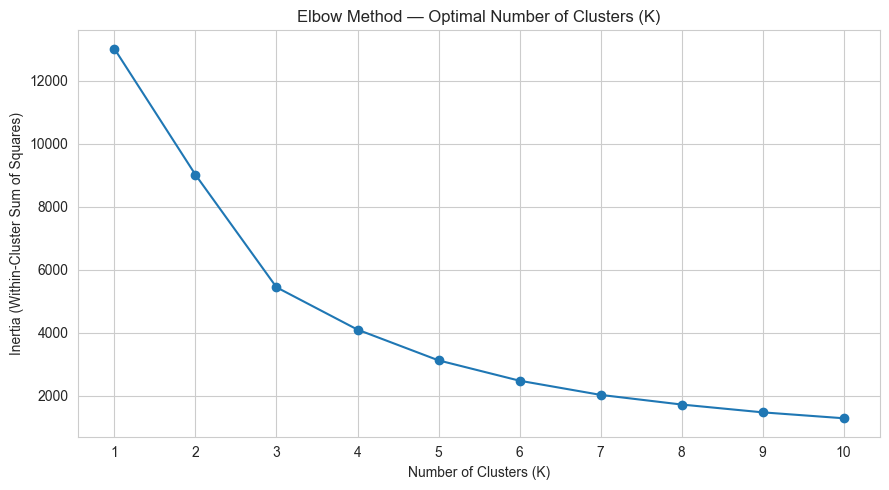

In [16]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method — Optimal Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


**Observation (fill in):**"The elbow chart shows inertia dropping sharply from K=1 to K=3, then flattening noticeably from K=4 onward. This confirms K=4 is a reasonable choice — adding more clusters beyond 4 gives diminishing returns in explaining the variance in customer behaviour, so we keep the model simple and interpretable with 4 segments."


In [17]:
optimal_k = 4   # <-- set this based on the elbow chart above

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


## Step 6 — Visualise Clusters (Scatter Plots)
Two different feature-pair views of the same clusters.


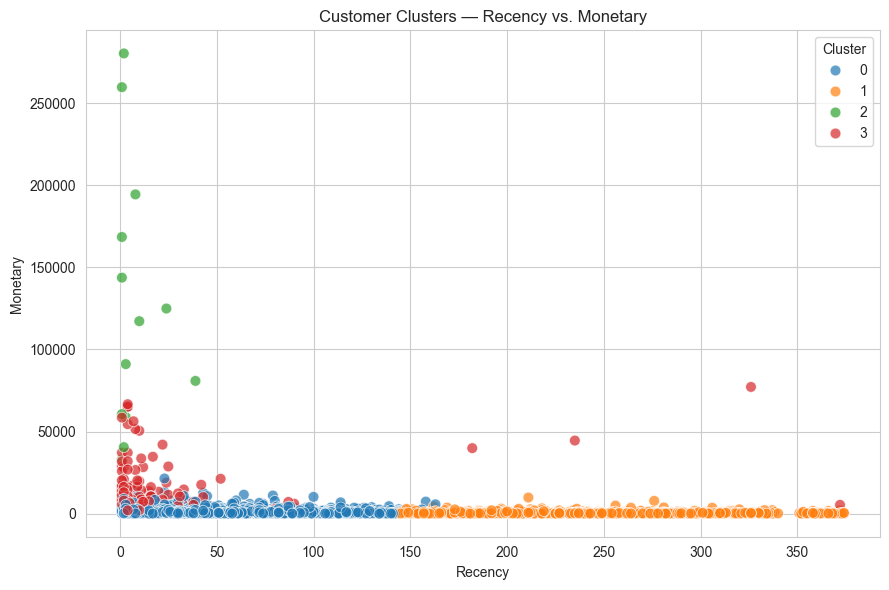

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='tab10', s=60, alpha=0.7)
plt.title('Customer Clusters — Recency vs. Monetary')
plt.tight_layout()
plt.show()


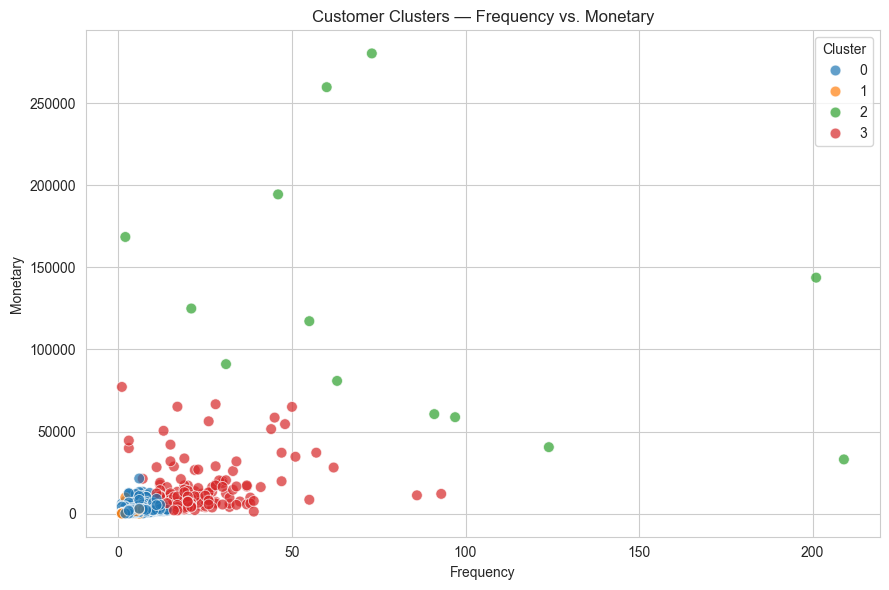

In [19]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='tab10', s=60, alpha=0.7)
plt.title('Customer Clusters — Frequency vs. Monetary')
plt.tight_layout()
plt.show()


**Observation (fill in):** "Cluster 2 (green) clearly stands out with very high Monetary values (up to ₹250K+) despite low Recency, marking these as high-value, recently active customers — likely the most important segment for the business. Cluster 3 (red) shows moderate monetary value concentrated at low recency. Clusters 0 (blue) and 1 (orange) both cluster near zero Monetary value, but differ in Recency — Cluster 0 sits at low recency (recently active but low spenders) while Cluster 1 spreads across higher recency values (less recently active, low spenders)."  "This view confirms Cluster 2 (green) as the standout high-value segment, combining both high Monetary value and, in several cases, high Frequency (one customer purchasing 200+ times). Cluster 3 (red) shows moderate frequency and monetary value, representing a middle tier. Clusters 0 and 1 both cluster tightly near the origin with low frequency and low monetary value, reinforcing that these are lower-engagement customer groups."


## Step 7 — Profile Each Cluster
Mean feature values per cluster, to describe each customer type in plain business terms.


In [20]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Customer Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile


,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,43.7,3.7,1353.6,3054
1,248.1,1.6,478.8,1067
2,7.4,82.5,127188.0,13
3,15.5,22.3,12690.5,204


**Observation (fill in):** Cluster 0 (Recency 43.7, Frequency 3.7, Monetary ₹1,353.6, 3,054 customers) → Regular / Average customers. The largest group by far — moderately recent, low-to-moderate frequency, modest spend. This is the bulk of the customer base.
Cluster 1 (Recency 248.1, Frequency 1.6, Monetary ₹478.8, 1,067 customers) → At-risk / Churned customers. Haven't purchased in ~248 days on average, very low frequency and spend — these customers are drifting away or already lost.
Cluster 2 (Recency 7.4, Frequency 82.5, Monetary ₹127,188.0, 13 customers) → VIP / Champion customers. An extremely small but extraordinarily valuable group — purchased very recently, extremely frequently (82+ orders), and spend nearly ₹100x more than average. These 13 customers likely drive a disproportionate share of total revenue.
Cluster 3 (Recency 15.5, Frequency 22.3, Monetary ₹12,690.5, 204 customers) → Loyal / High-value customers. Recently active, solid purchase frequency, and strong spend — not quite VIP-tier, but clearly engaged, valuable repeat customers.

## Step 8 — Number of Customers per Cluster

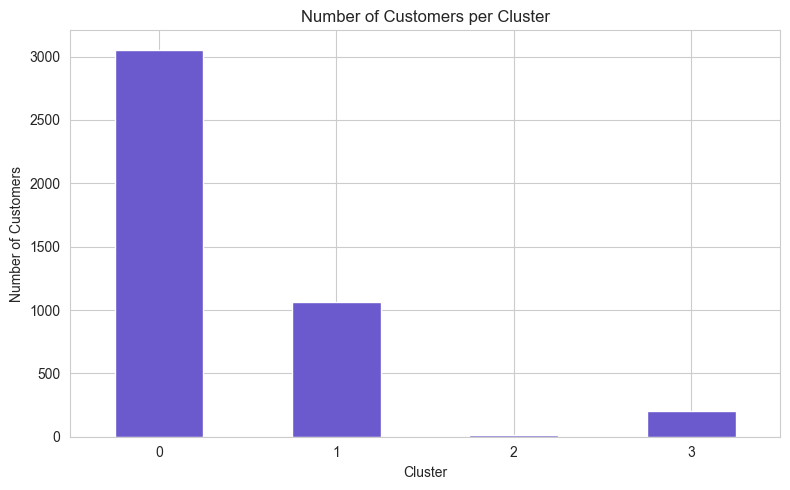

In [21]:
plt.figure(figsize=(8, 5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='slateblue')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation (fill in):** "Customer distribution is heavily imbalanced: Cluster 0 dominates with roughly 3,000 customers (the majority of the customer base), followed by Cluster 1 at around 1,050. Clusters 2 and 3 are much smaller — Cluster 2 (the high-value 'VIP' segment identified in the scatter plots) contains only a handful of customers, while Cluster 3 has around 700. This is a classic and expected pattern in RFM segmentation: a small number of highly valuable customers (Cluster 2) sit alongside a much larger base of average or low-engagement customers (Cluster 0)."


## Step 9 — Insights: Marketing Recommendations per Segment

Cluster 2 — VIP / Champion customers (13 customers, ₹127K avg spend): Assign a dedicated account manager or VIP loyalty tier with exclusive perks (early access, personal outreach). Losing even one of these customers has an outsized revenue impact, so retention here is the highest priority despite the small group size.
Cluster 3 — Loyal / High-value customers (204 customers, ₹12.7K avg spend): Nurture toward VIP status with a tiered loyalty program, personalized product recommendations, and occasional exclusive discounts to increase frequency further.
Cluster 0 — Regular / Average customers (3,054 customers, ₹1.35K avg spend): The largest segment — focus on cross-sell/upsell campaigns and habit-building incentives (e.g. "buy 3 more times this quarter for a reward") to nudge them toward Cluster 3.
Cluster 1 — At-risk / Churned customers (1,067 customers, ~248 days inactive): Launch a win-back email campaign with a time-limited discount. If no response within a defined window, deprioritize marketing spend on this group to focus resources on higher-potential segments.

## Conclusion

**Summary of key findings:**
1. *Four distinct customer segments emerged from RFM-based K-Means clustering, ranging from a large base of average customers (Cluster 0, 3,054 customers) to a tiny but extremely high-value VIP group (Cluster 2, just 13 customers averaging ₹127,188 in spend).*
2. *Customer value is highly concentrated — the top-tier segments (Clusters 2 and 3, only 217 customers combined) likely account for a disproportionate share of total revenue compared to the much larger low-value segments.*
3. *A meaningful portion of the customer base (Cluster 1, 1,067 customers) shows signs of churn, with an average recency of 248 days since last purchase.*

**Business impact:** Segmenting customers via RFM + K-Means allows the marketing team to move away from one-size-fits-all campaigns and instead protect and grow the small but critical VIP segment, nurture loyal customers toward VIP status, and run targeted win-back campaigns for at-risk customers — rather than spending equally across a customer base with wildly different value profiles.